# On-Device Architecture Benchmark for WiFi CSI HAR (UT-HAR)

Trains five architecture families on UT-HAR with one shared pipeline, then exports each
to **int8 TFLite** for ESP32-S3 deployment and records accuracy, parameters, model size,
and int8-conversion feasibility.

Architectures: **1D-CNN, BiGRU, Transformer, Chebyshev-KAN, lightweight-SSM.**

Dataset: attach **hylanj/wifi-csi-dataset-ut-har**. Settings: GPU **T4 x2**, Internet On.

Outputs to `/kaggle/working/`: `benchmark_results.json`, `benchmark_table.csv`,
`tflite/*.tflite` (deploy these to the ESP32), `benchmark_plot.png`.
The on-device latency/RAM/energy columns stay TBR until the ESP32 measurements.


In [1]:
import os, json, time, math, warnings
from pathlib import Path
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
print("TF", tf.__version__, "| GPUs:", tf.config.list_physical_devices('GPU'))
OUT = Path("/kaggle/working"); OUT.mkdir(exist_ok=True)
(OUT/"tflite").mkdir(exist_ok=True)
SEEDS = 3
EPOCHS = 40
TARGET_T = 32   # downsample UT-HAR's 250-step window so int8 arenas fit a PSRAM-less ESP32


2026-06-07 12:25:01.274550: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780835101.452450      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780835101.507756      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780835101.975900      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780835101.975949      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780835101.975968      23 computation_placer.cc:177] computation placer alr

TF 2.19.0 | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ----- UT-HAR loader (SenseFi .npy-as-.csv in data/ + label/ folders) -----
def _find(name):
    hits = list(Path("/kaggle/input").rglob(name))
    return sorted(hits, key=lambda p: len(str(p)))[0] if hits else None

def _load(path):
    try:
        with open(path, "rb") as f:
            return np.asarray(np.load(f, allow_pickle=True))
    except Exception:
        return np.genfromtxt(str(path), delimiter=",")

def load_ut_har():
    paths = {k: _find(f"{k}.csv") for k in ["X_train","y_train","X_test","y_test"]}
    miss = [k for k,v in paths.items() if v is None]
    if miss:
        raise FileNotFoundError(f"missing {miss}; CSVs found: {list(Path('/kaggle/input').rglob('*.csv'))[:10]}")
    for k,v in paths.items(): print(f"  {k}: {v}")
    ytr = _load(paths["y_train"]).astype(np.int64).flatten()
    yte = _load(paths["y_test"]).astype(np.int64).flatten()
    Xtr = _load(paths["X_train"]).astype(np.float32)
    Xte = _load(paths["X_test"]).astype(np.float32)
    def seq(x, n):
        x = np.asarray(x)
        if x.ndim==3 and x.shape[1]==250 and x.shape[2]==90: return x
        if x.ndim==3 and x.shape[1]==90 and x.shape[2]==250: return x.transpose(0,2,1)
        if x.ndim==2 and x.shape[1]==250*90: return x.reshape(-1,250,90)
        return x.reshape(n,250,90)
    Xtr, Xte = seq(Xtr,len(ytr)), seq(Xte,len(yte))
    # downsample the time axis to TARGET_T (evenly-spaced) to shrink on-device arenas
    def dsT(x, T):
        if x.shape[1]==T: return x
        idx=np.linspace(0, x.shape[1]-1, T).astype(int)
        return x[:, idx, :]
    Xtr, Xte = dsT(Xtr, TARGET_T), dsT(Xte, TARGET_T)
    def norm(x):
        m=x.mean(axis=(1,2),keepdims=True); s=x.std(axis=(1,2),keepdims=True)+1e-8
        return ((x-m)/s).astype(np.float32)
    Xtr, Xte = norm(Xtr), norm(Xte)
    print(f"  train {Xtr.shape} test {Xte.shape} (T={TARGET_T}) classes {sorted(set(ytr.tolist()))}")
    return Xtr, ytr, Xte, yte


In [3]:
# ----- Chebyshev-KAN dense layer (TFLite-friendly: matmul, no einsum) -----
class ChebyKAN(layers.Layer):
    def __init__(self, out_dim, degree=3, **kw):
        super().__init__(**kw); self.out_dim=out_dim; self.degree=degree
    def build(self, shape):
        self.in_dim=int(shape[-1])
        self.coeff=self.add_weight(name="coeff",
            shape=(self.in_dim*(self.degree+1), self.out_dim),
            initializer=tf.keras.initializers.GlorotUniform())
    def call(self, x):
        x=tf.tanh(x)                                   # (B,in) in [-1,1]
        Ts=[tf.ones_like(x), x]
        for k in range(2,self.degree+1):
            Ts.append(2.0*x*Ts[-1]-Ts[-2])
        T=tf.concat(Ts,axis=-1)                        # (B, in*(deg+1))
        return tf.matmul(T, self.coeff)                # (B,out)

# ----- lightweight diagonal SSM layer via Keras RNN cell (deployment-honest) -----
class DiagSSMCell(layers.Layer):
    def __init__(self, units, **kw):
        super().__init__(**kw); self.units=units; self.state_size=units
    def build(self, shape):
        d=int(shape[-1])
        self.A=self.add_weight(name="A",shape=(self.units,),initializer=tf.keras.initializers.RandomUniform(-0.99,0.99))
        self.B=self.add_weight(name="B",shape=(d,self.units),initializer="glorot_uniform")
        self.C=self.add_weight(name="C",shape=(self.units,d),initializer="glorot_uniform")
    def call(self, inputs, states):
        h=states[0]*tf.tanh(self.A)+tf.matmul(inputs,self.B)
        y=tf.matmul(h,self.C)
        return y, [h]


In [4]:
# ----- Model builders (T=250, F=90, n_classes) -----
def m_cnn(T,F,n):
    i=layers.Input((T,F)); x=layers.Conv1D(64,7,padding="same",activation="relu")(i)
    x=layers.BatchNormalization()(x); x=layers.MaxPool1D(2)(x)
    x=layers.Conv1D(128,5,padding="same",activation="relu")(x)
    x=layers.BatchNormalization()(x); x=layers.GlobalAveragePooling1D()(x)
    x=layers.Dense(64,activation="relu")(x); o=layers.Dense(n)(x)
    return Model(i,o,name="CNN")

def m_gru(T,F,n):
    i=layers.Input((T,F)); x=layers.Bidirectional(layers.GRU(64))(i)
    x=layers.Dense(64,activation="relu")(x); o=layers.Dense(n)(x)
    return Model(i,o,name="BiGRU")

def m_transformer(T,F,n):
    i=layers.Input((T,F)); x=layers.Conv1D(64,5,padding="same")(i)
    a=layers.MultiHeadAttention(num_heads=4,key_dim=16)(x,x)
    x=layers.LayerNormalization()(x+a)
    f=layers.Dense(128,activation="relu")(x); f=layers.Dense(64)(f)
    x=layers.LayerNormalization()(x[...,:64]+f) if False else layers.LayerNormalization()(f)
    x=layers.GlobalAveragePooling1D()(x); o=layers.Dense(n)(x)
    return Model(i,o,name="Transformer")

def m_kan(T,F,n):
    i=layers.Input((T,F)); x=layers.Conv1D(64,7,padding="same",activation="relu")(i)
    x=layers.MaxPool1D(2)(x); x=layers.Conv1D(64,5,padding="same",activation="relu")(x)
    x=layers.GlobalAveragePooling1D()(x)
    x=ChebyKAN(64,degree=3)(x); o=ChebyKAN(n,degree=3)(x)
    return Model(i,o,name="ChebyKAN")

def m_ssm(T,F,n):
    i=layers.Input((T,F)); x=layers.Conv1D(64,5,padding="same",activation="relu")(i)
    x=layers.RNN(DiagSSMCell(64))(x)
    x=layers.Dense(64,activation="relu")(x); o=layers.Dense(n)(x)
    return Model(i,o,name="SSM")

BUILDERS={"CNN":m_cnn,"BiGRU":m_gru,"Transformer":m_transformer,"ChebyKAN":m_kan,"SSM":m_ssm}


In [5]:
def train_eval(builder, Xtr,ytr,Xte,yte,n,seed):
    tf.keras.utils.set_random_seed(seed)
    model=builder(Xtr.shape[1],Xtr.shape[2],n)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"])
    model.fit(Xtr,ytr,validation_data=(Xte,yte),epochs=EPOCHS,batch_size=64,verbose=0)
    logits=model.predict(Xte,verbose=0); yp=logits.argmax(-1)
    acc=float(accuracy_score(yte,yp)); f1=float(f1_score(yte,yp,average="macro"))
    kappa=float(cohen_kappa_score(yte,yp))
    params=int(model.count_params())
    return model, dict(acc=acc,f1=f1,kappa=kappa,params=params)

def to_int8(model, Xtr, name):
    def rep():
        for i in range(min(300,len(Xtr))):
            yield [Xtr[i:i+1].astype(np.float32)]
    def make(src):
        if src=="keras":
            c=tf.lite.TFLiteConverter.from_keras_model(model)
        else:
            d=str(OUT/"sm"/name)
            try: model.export(d)
            except Exception: tf.saved_model.save(model,d)
            c=tf.lite.TFLiteConverter.from_saved_model(d)
        c.optimizations=[tf.lite.Optimize.DEFAULT]; c.representative_dataset=rep
        c.target_spec.supported_ops=[tf.lite.OpsSet.TFLITE_BUILTINS_INT8,
                                     tf.lite.OpsSet.TFLITE_BUILTINS]  # builtins fallback
        return c
    last=None
    # try (source, io-type) combos: full-int8 first (ESP32-ideal), then float-io
    for src in ["keras","savedmodel"]:
        for io in ["int8","float"]:
            try:
                c=make(src)
                if io=="int8":
                    c.inference_input_type=tf.int8; c.inference_output_type=tf.int8
                blob=c.convert()
                (OUT/"tflite"/f"{name}_int8.tflite").write_bytes(blob)
                return len(blob), f"{src}/{io}-io"
            except Exception as e:
                last=e
    raise last

def eval_tflite(path, Xte, yte):
    it=tf.lite.Interpreter(model_path=str(path)); it.allocate_tensors()
    inp=it.get_input_details()[0]; out=it.get_output_details()[0]
    preds=[]
    for i in range(len(Xte)):
        x=Xte[i:i+1]
        if inp["dtype"]==np.int8:
            s,z=inp["quantization"]; x=np.clip(np.round(x/s+z),-128,127).astype(np.int8)
        it.set_tensor(inp["index"],x); it.invoke()
        preds.append(it.get_tensor(out["index"])[0].argmax())
    return float(accuracy_score(yte,np.array(preds)))


In [6]:
Xtr,ytr,Xte,yte=load_ut_har()
N=int(max(ytr.max(),yte.max()))+1
results={}
for name,builder in BUILDERS.items():
    print("="*60); print(name); print("="*60)
    try:
        accs=[]; f1s=[]; kappas=[]; params=0; best=None; best_acc=-1
        for s in range(SEEDS):
            model,m=train_eval(builder,Xtr,ytr,Xte,yte,N,s)
            accs.append(m["acc"]); f1s.append(m["f1"]); kappas.append(m["kappa"]); params=m["params"]
            print(f"  seed{s}: acc {m['acc']:.4f} f1 {m['f1']:.4f} kappa {m['kappa']:.4f}")
            if m["acc"]>best_acc: best_acc=m["acc"]; best=model
        # accuracy is recorded regardless of whether the model converts to TFLite
        res=dict(acc_mean=float(np.mean(accs)),acc_std=float(np.std(accs)),
                 f1_mean=float(np.mean(f1s)),kappa_mean=float(np.mean(kappas)),params=params,
                 fp32_kb=-1,int8_kb=-1,int8_acc=0.0,int8_type="-",convert_ok=False)
        # fp32 size (best effort; some ops are not TFLite-convertible)
        try:
            fp32=OUT/"tflite"/f"{name}_fp32.tflite"
            fp32.write_bytes(tf.lite.TFLiteConverter.from_keras_model(best).convert())
            res["fp32_kb"]=round(fp32.stat().st_size/1024,1)
        except Exception as e:
            print(f"  fp32 convert n/a: {type(e).__name__}")
        # int8 export + eval (the MCU-deployability gate)
        try:
            sz,itype=to_int8(best,Xtr,name)
            ia=eval_tflite(OUT/"tflite"/f"{name}_int8.tflite",Xte,yte)
            res.update(int8_kb=round(sz/1024,1),int8_acc=ia,int8_type=itype,convert_ok=True)
        except Exception as e:
            res["int8_type"]=f"NO_MCU:{type(e).__name__}"
            print(f"  int8 export failed (not MCU-deployable): {type(e).__name__}")
        results[name]=res
        print(f"  -> acc {res['acc_mean']*100:.2f}±{res['acc_std']*100:.2f} | params {params/1e3:.1f}K "
              f"| int8 {res['int8_kb']}kB | int8_acc {res['int8_acc']:.4f} | convert {res['convert_ok']}")
    except Exception as e:
        results[name]=dict(error=f"{type(e).__name__}: {e}")
        print(f"  MODEL FAILED (training): {e}")
json.dump(results,open(OUT/"benchmark_results.json","w"),indent=2)
print("\nsaved benchmark_results.json")


  X_train: /kaggle/input/datasets/hylanj/wifi-csi-dataset-ut-har/data/X_train.csv
  y_train: /kaggle/input/datasets/hylanj/wifi-csi-dataset-ut-har/label/y_train.csv
  X_test: /kaggle/input/datasets/hylanj/wifi-csi-dataset-ut-har/data/X_test.csv
  y_test: /kaggle/input/datasets/hylanj/wifi-csi-dataset-ut-har/label/y_test.csv
  train (3977, 32, 90) test (500, 32, 90) (T=32) classes [0, 1, 2, 3, 4, 5, 6]
CNN


I0000 00:00:1780835121.225926      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1780835124.499044      68 service.cc:152] XLA service 0x7cf24400de50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780835124.499083      68 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780835124.878960      68 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780835126.978544      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  seed0: acc 0.9820 f1 0.9706 kappa 0.9778
  seed1: acc 0.9800 f1 0.9687 kappa 0.9753
  seed2: acc 0.9800 f1 0.9670 kappa 0.9753
INFO:tensorflow:Assets written to: /tmp/tmpmbfnsti3/assets


INFO:tensorflow:Assets written to: /tmp/tmpmbfnsti3/assets


Saved artifact at '/tmp/tmpmbfnsti3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 90), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  137383641162064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137383641163216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137383641162256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137383641159952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137383641161296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137383641163600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137383641162448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137383641163792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137383641164752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137383641164944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137383641161104: Te

...

W0000 00:00:1780835435.311130      23 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1780835435.311201      23 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
loc(callsite(callsite(fused["TensorListReserve:", "SSM_1/rnn_1_1/TensorArrayV2_1@__inference___call___258317"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper___call___258364"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): error: 'tf.TensorListReserve' op requires element_shape to be static during TF Lite transformation pass
loc(callsite(callsite(fused["TensorListReserve:", "SSM_1/rnn_1_1/TensorArrayV2_1@__inference___call___258317"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper___call___258364"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): error: failed to legalize operation 'tf.TensorListReserve' that was explicitly marked illegal
error: Lowering tens

INFO:tensorflow:Assets written to: /kaggle/working/sm/SSM/assets


INFO:tensorflow:Assets written to: /kaggle/working/sm/SSM/assets


Saved artifact at '/kaggle/working/sm/SSM'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 90), dtype=tf.float32, name='keras_tensor_95')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  137380845891856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137380046755728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137380046753424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137380046756880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137380046754576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137380046761872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137380046749968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137380046756304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137380082357392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  int8 export failed (not MCU-deployable): ConverterError
  -> acc 92.33±1.79 | pa

W0000 00:00:1780835436.392857      23 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1780835436.392902      23 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
loc(callsite(callsite(fused["TensorListReserve:", "SSM_1/rnn_1_1/TensorArrayV2_1@__inference___call___259909"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper___call___259956"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): error: 'tf.TensorListReserve' op requires element_shape to be static during TF Lite transformation pass
loc(callsite(callsite(fused["TensorListReserve:", "SSM_1/rnn_1_1/TensorArrayV2_1@__inference___call___259909"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper___call___259956"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): error: failed to legalize operation 'tf.TensorListReserve' that was explicitly marked illegal
error: Lowering tens

      Model     Acc(%)    F1 Params(K) fp32(kB) int8(kB) int8 Acc(%) Converts Latency(ms) RAM(kB) Energy(mJ)
        CNN 98.07±0.09 0.969      91.0    360.4    102.9       98.00      yes         TBR     TBR        TBR
      BiGRU 98.13±0.34 0.974      68.6      n/a      n/a         n/a       no         n/a     n/a        n/a
Transformer 96.67±0.62 0.948      62.8    258.5     88.3       97.40      yes         TBR     TBR        TBR
   ChebyKAN 97.47±0.77 0.965      79.1    316.2     90.4       98.40      yes         TBR     TBR        TBR
        SSM 92.33±1.79 0.902      41.7      n/a      n/a         n/a       no         n/a     n/a        n/a


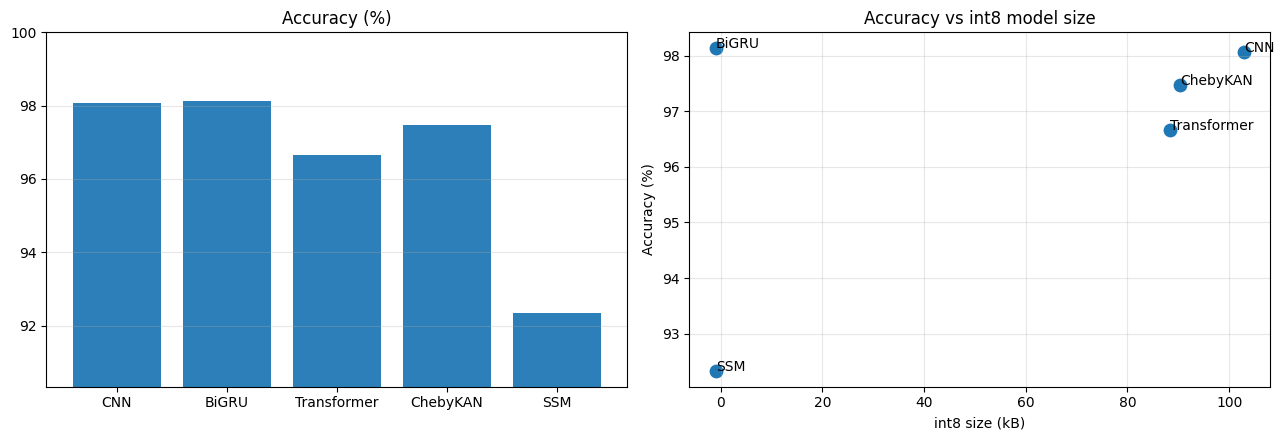


DONE. Deploy /kaggle/working/tflite/*_int8.tflite to the ESP32 for latency/RAM/energy.


In [7]:
import pandas as pd
rows=[]
for name,r in results.items():
    if "error" in r:
        rows.append({"Model":name,"Acc(%)":"FAILED","F1":"-","Params(K)":"-",
                     "fp32(kB)":"-","int8(kB)":"-","int8 Acc(%)":"-","Converts":"no"})
        continue
    rows.append({"Model":name,
        "Acc(%)":f"{r['acc_mean']*100:.2f}±{r['acc_std']*100:.2f}",
        "F1":f"{r['f1_mean']:.3f}","Params(K)":f"{r['params']/1e3:.1f}",
        "fp32(kB)":(r["fp32_kb"] if r["fp32_kb"]>0 else "n/a"),
        "int8(kB)":(r["int8_kb"] if r["convert_ok"] else "n/a"),
        "int8 Acc(%)":(f"{r['int8_acc']*100:.2f}" if r["convert_ok"] else "n/a"),
        "Converts":"yes" if r["convert_ok"] else "no",
        "Latency(ms)":("TBR" if r["convert_ok"] else "n/a"),
        "RAM(kB)":("TBR" if r["convert_ok"] else "n/a"),
        "Energy(mJ)":("TBR" if r["convert_ok"] else "n/a")})
tbl=pd.DataFrame(rows); print(tbl.to_string(index=False))
tbl.to_csv(OUT/"benchmark_table.csv",index=False)

ok={k:v for k,v in results.items() if "error" not in v}
if ok:
    fig,ax=plt.subplots(1,2,figsize=(13,4.5))
    names=list(ok); accs=[ok[k]["acc_mean"]*100 for k in names]
    sizes=[ok[k]["int8_kb"] for k in names]; params=[ok[k]["params"]/1e3 for k in names]
    ax[0].bar(names,accs,color="#2c7fb8"); ax[0].set_title("Accuracy (%)"); ax[0].set_ylim(min(accs)-2,100)
    ax[0].grid(axis="y",alpha=0.3)
    ax[1].scatter(sizes,accs,s=80)
    for k,x,y in zip(names,sizes,accs): ax[1].annotate(k,(x,y))
    ax[1].set_xlabel("int8 size (kB)"); ax[1].set_ylabel("Accuracy (%)")
    ax[1].set_title("Accuracy vs int8 model size"); ax[1].grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(OUT/"benchmark_plot.png",dpi=120); plt.show()
print("\nDONE. Deploy /kaggle/working/tflite/*_int8.tflite to the ESP32 for latency/RAM/energy.")


## Done
Download from `/kaggle/working/`: `benchmark_table.csv`, `benchmark_results.json`,
`benchmark_plot.png`, and `tflite/*_int8.tflite`.

The accuracy / params / size / int8-conversion columns are now filled. The
**Latency / RAM / Energy** columns are TBR — measured next on the ESP32-S3 by flashing
each `*_int8.tflite` and timing inference. See the ESP32 deployment guide.
